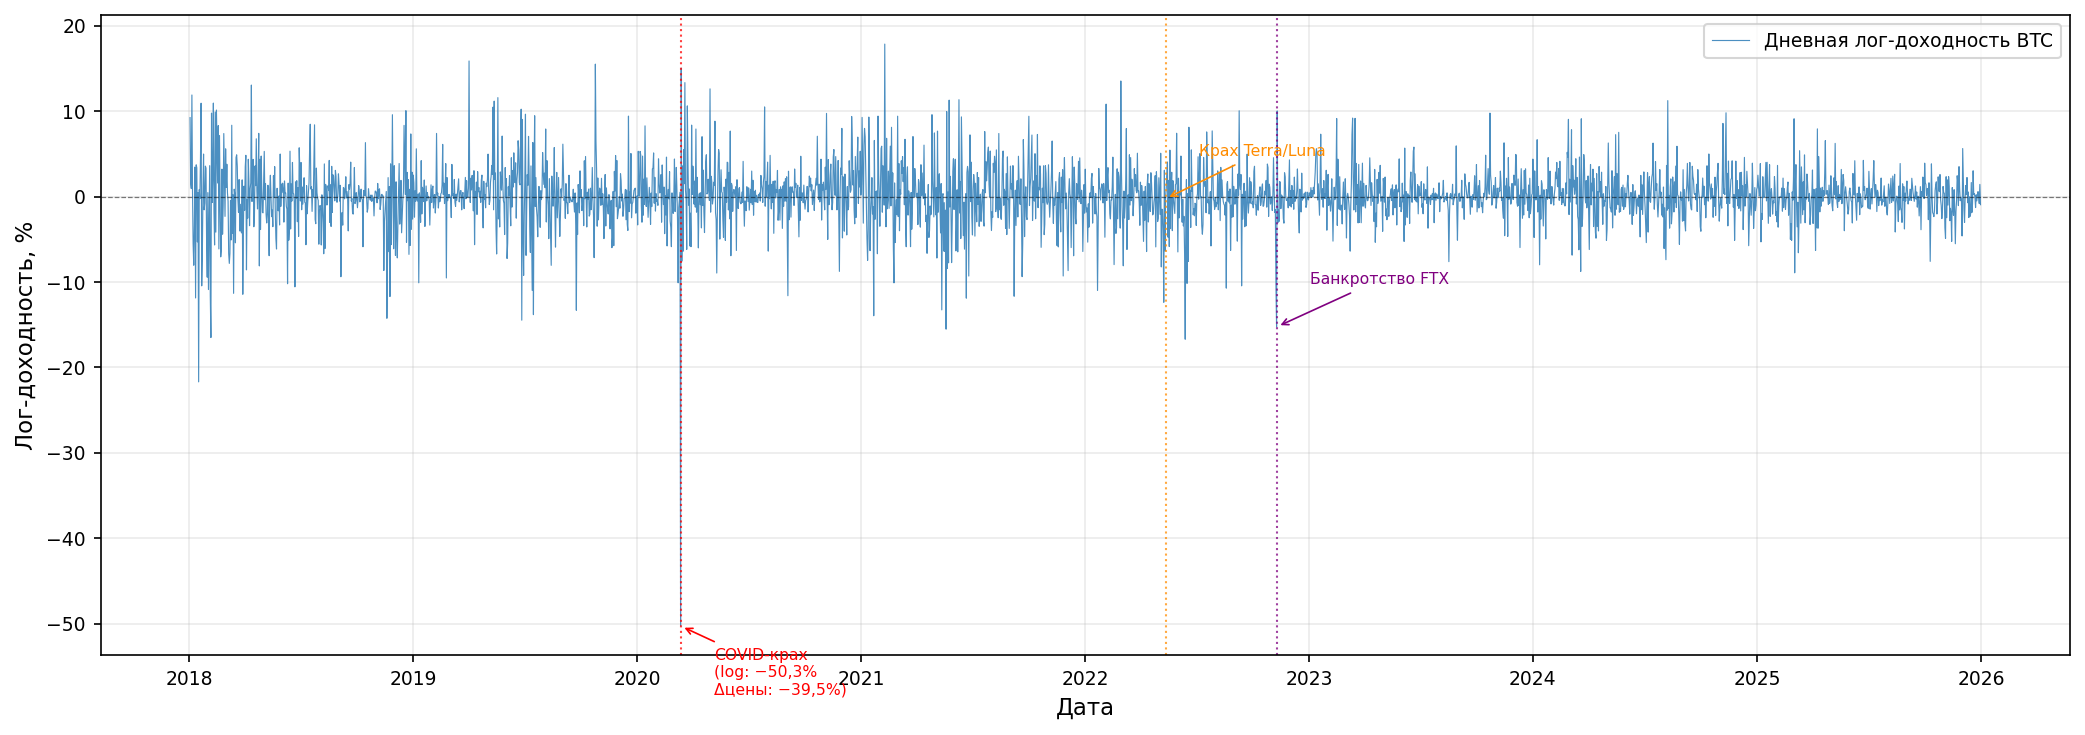

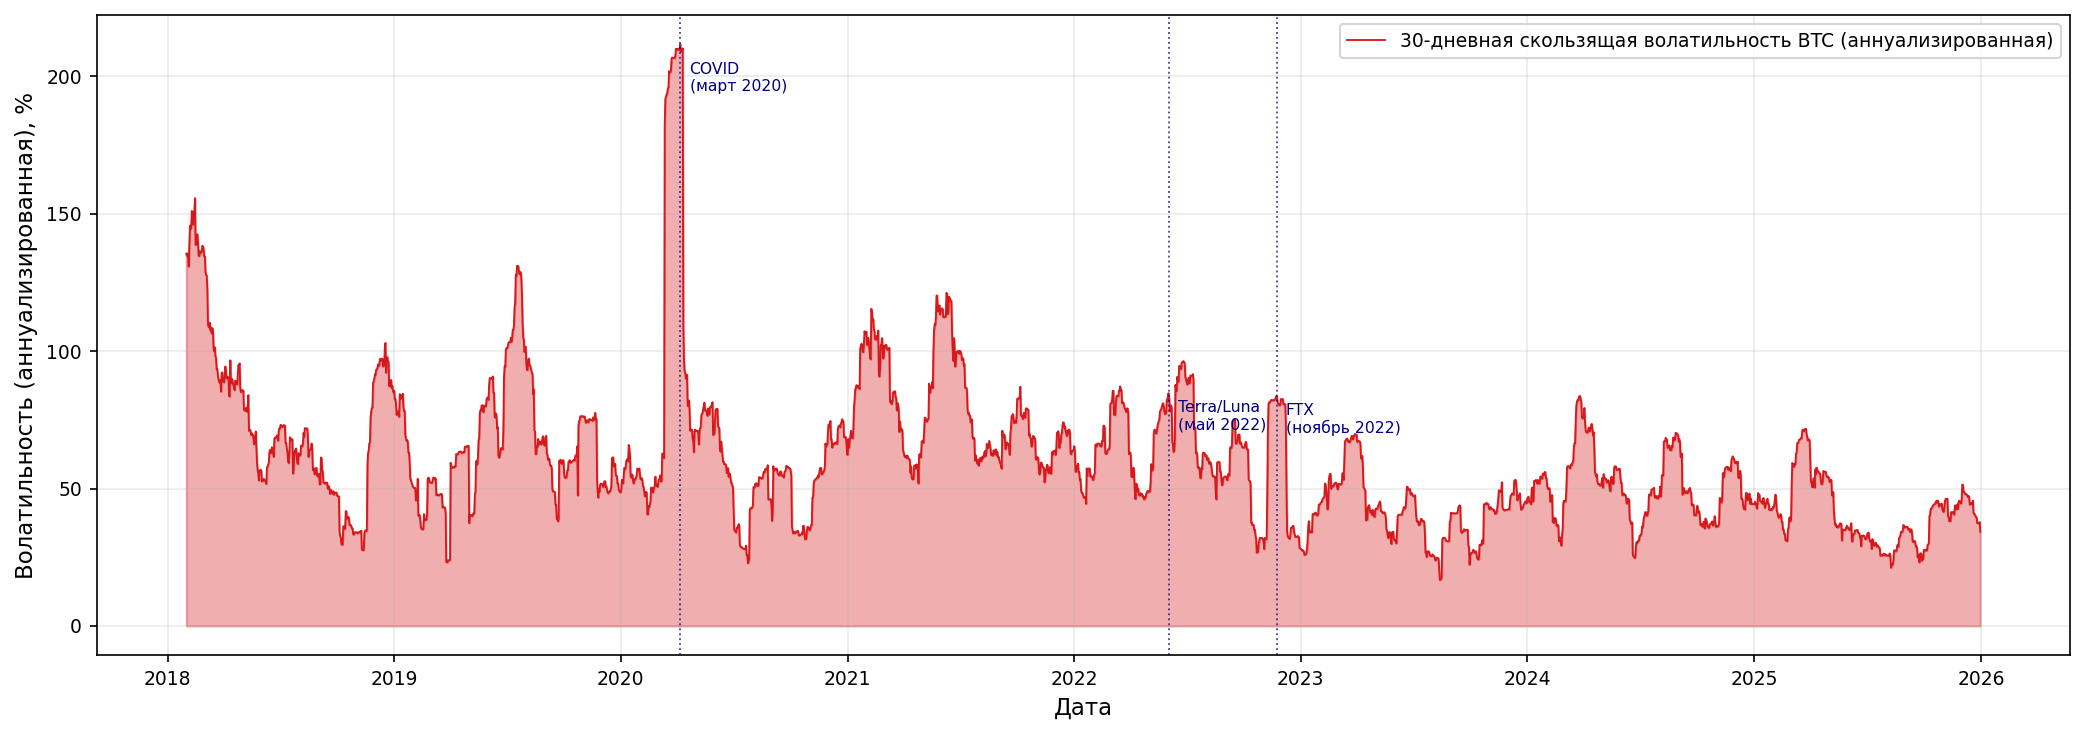

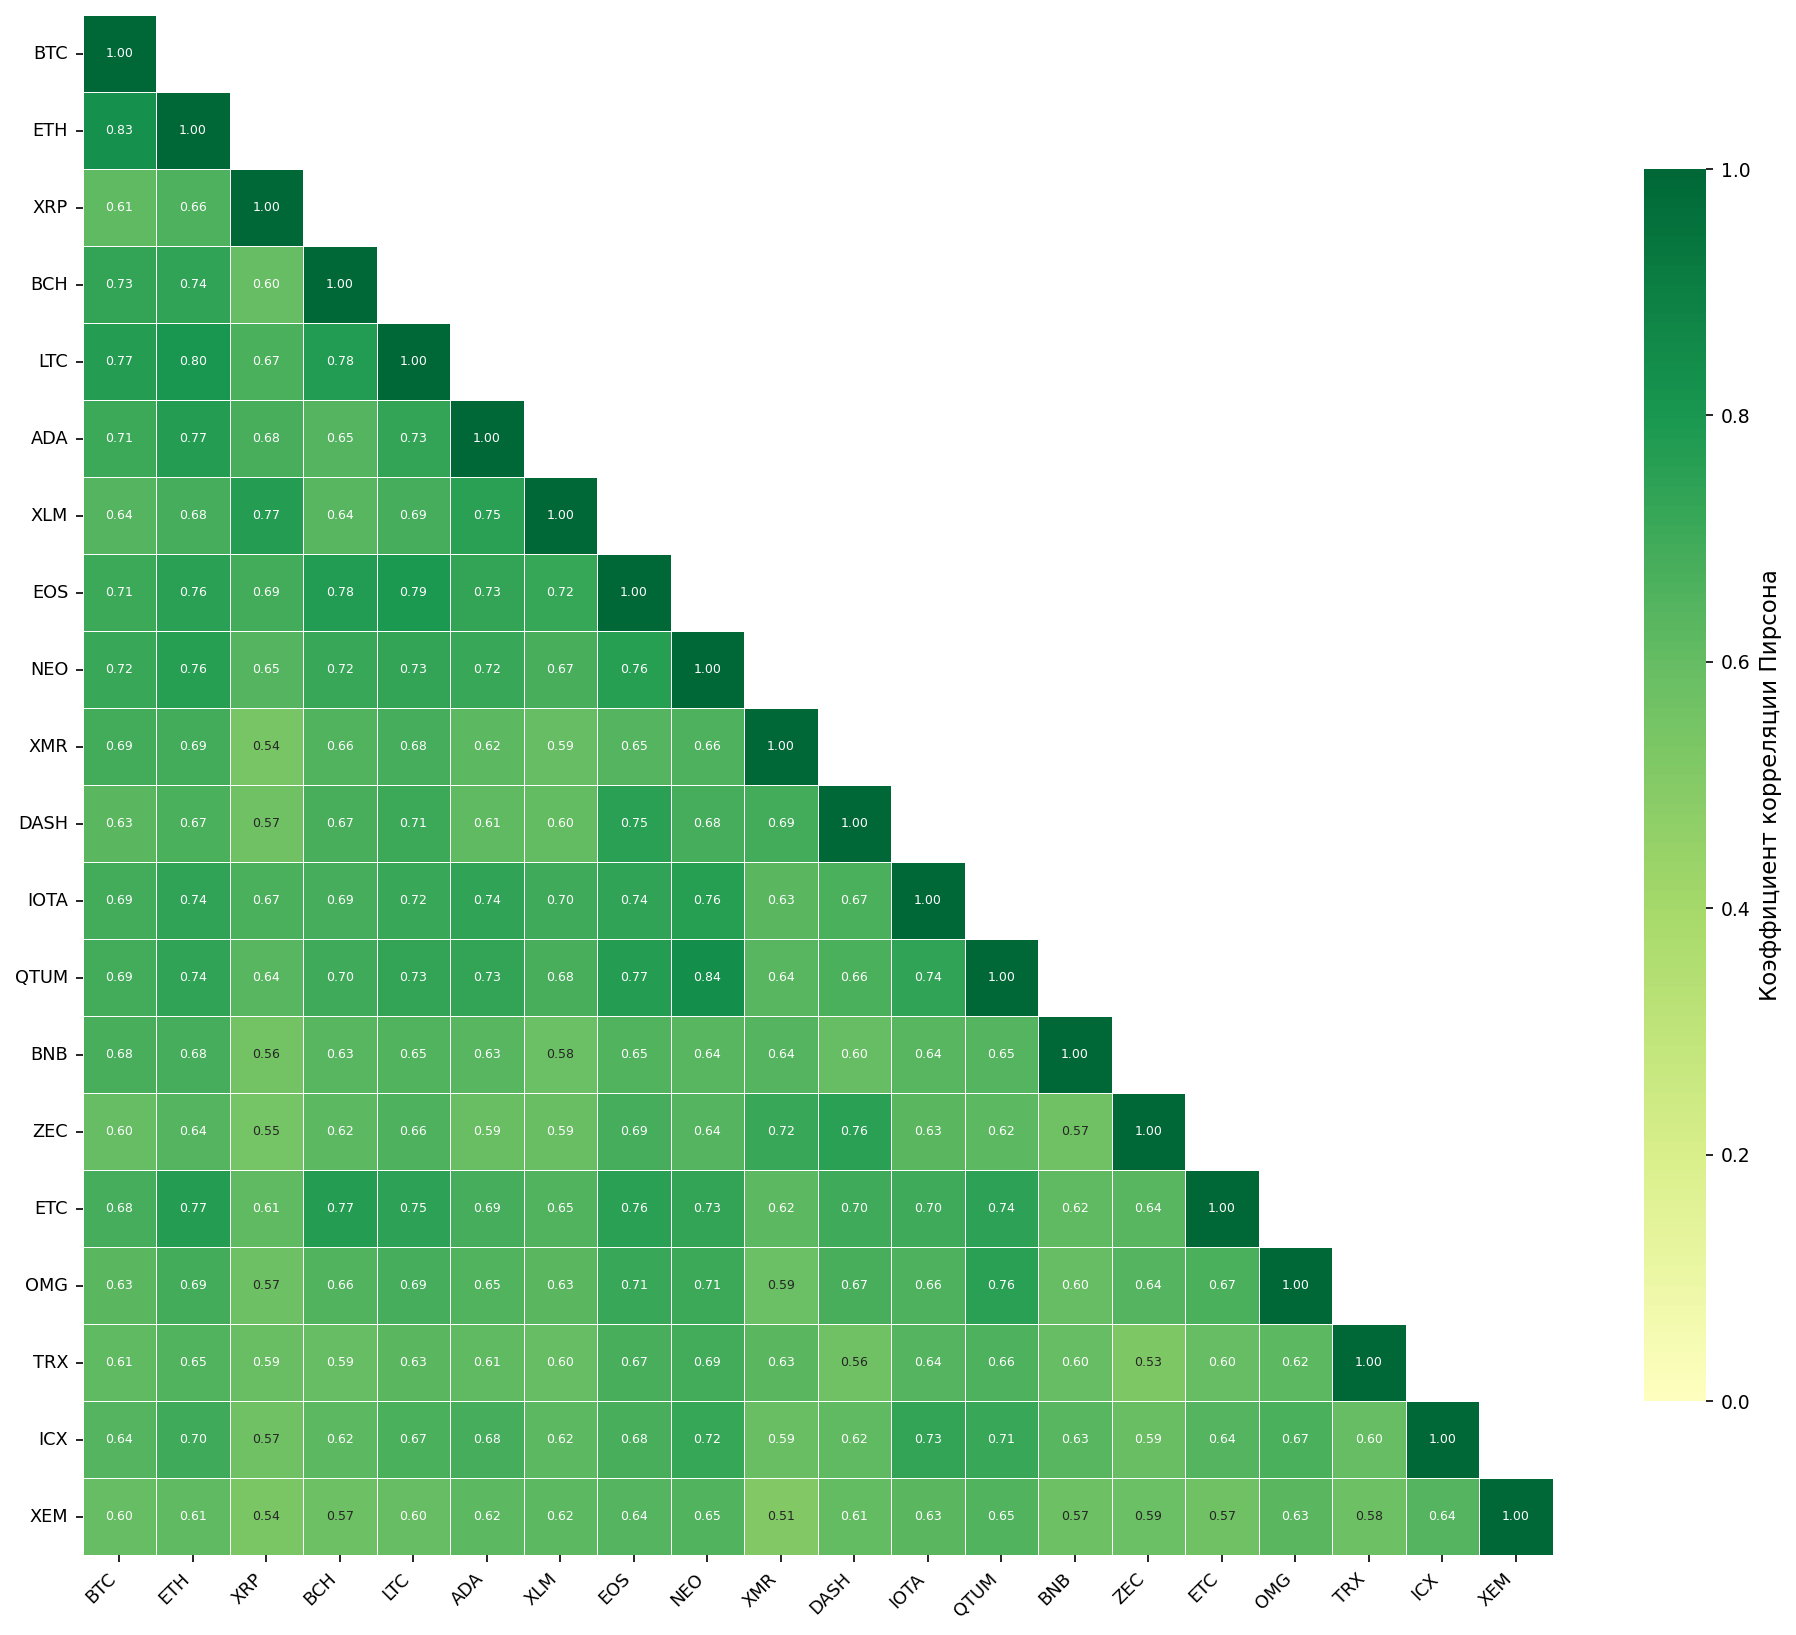

In [1]:
# -------------------------------------------------------
# 0. Импорт библиотек
# -------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import time
import warnings
from scipy import stats
from statsmodels.stats.diagnostic import (
    acorr_ljungbox, het_arch
)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'axes.titlesize':  13,
    'axes.labelsize':  11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'figure.dpi':      150
})

# -------------------------------------------------------
# 1. Параметры выборки
# -------------------------------------------------------

# Топ-20 криптовалютных пар к USDT по рыночной
# капитализации на дату начала выборки — 01.01.2018
SYMBOLS = [
    'BTCUSDT',  'ETHUSDT',  'XRPUSDT',  'BCHUSDT',
    'LTCUSDT',  'ADAUSDT',  'XLMUSDT',  'EOSUSDT',
    'NEOUSDT',  'XMRUSDT',  'DASHUSDT', 'IOTAUSDT',
    'QTUMUSDT', 'BNBUSDT',  'ZECUSDT',  'ETCUSDT',
    'OMGUSDT',  'TRXUSDT',  'ICXUSDT',  'XEMUSDT'
]

START_DATE = '2018-01-01'
END_DATE   = '2025-12-31'

# -------------------------------------------------------
# 2. Загрузка данных с Binance
# -------------------------------------------------------

def fetch_binance_klines(
        symbol, interval='1d',
        start=START_DATE, end=END_DATE):
    """
    Загрузка дневных OHLCV-данных с биржи Binance.
    Endpoint: GET /api/v3/klines
    Возвращает: pd.Series дневных цен закрытия.
    """
    url      = 'https://api.binance.com/api/v3/klines'
    start_ms = int(
        pd.Timestamp(start).timestamp() * 1000
    )
    end_ms   = int(
        pd.Timestamp(end).timestamp() * 1000
    )
    all_rows = []

    while start_ms < end_ms:
        params = {
            'symbol':    symbol,
            'interval':  interval,
            'startTime': start_ms,
            'endTime':   end_ms,
            'limit':     1000
        }
        r    = requests.get(url, params=params,
                            timeout=15)
        data = r.json()
        if not data or isinstance(data, dict):
            break
        all_rows.extend(data)
        start_ms = data[-1][0] + 1
        time.sleep(0.15)

    if not all_rows:
        return None

    df = pd.DataFrame(all_rows, columns=[
        'open_time', 'open', 'high', 'low',
        'close', 'volume', 'close_time',
        'quote_vol', 'trades',
        'taker_buy_base', 'taker_buy_quote', 'ignore'
    ])
    df['date']  = pd.to_datetime(
        df['open_time'], unit='ms'
    )
    df['close'] = df['close'].astype(float)
    df = df[df['close'] > 0]
    return df.set_index('date')['close']


closes = {}
for sym in SYMBOLS:
    try:
        s = fetch_binance_klines(sym)
        if s is not None and len(s) > 100:
            closes[sym] = s
    except Exception as e:
        print(f'Ошибка загрузки {sym}: {e}')

# Объединяем в DataFrame и вычисляем лог-доходности
# R_t = ln(P_t / P_{t-1})
closes_df = (
    pd.DataFrame(closes)
    .sort_index()
    .loc[START_DATE:END_DATE]
)

returns = np.log(closes_df / closes_df.shift(1))
returns = returns.dropna(how='all')

# -------------------------------------------------------
# 3. Расчёт описательных статистик (Таблица 5)
# -------------------------------------------------------
# Для каждого актива вычисляются: среднее, стандартное
# отклонение, минимум, максимум, асимметрия, избыточный
# эксцесс, а также p-значения трёх тестов:
#   — Жарка–Бера (нормальность распределения)
#   — Льюнга–Бокса (автокорреляция квадратов)
#   — ARCH-LM (наличие ARCH-эффектов)

def fmt_p(p):
    if p is None or np.isnan(p):
        return 'N/A'
    return '<0.001' if p < 0.001 else str(round(p, 3))

rows = []
for sym in returns.columns:
    r     = returns[sym].dropna()
    label = sym.replace('USDT', '')

    _, jb_p = stats.jarque_bera(r)

    lb   = acorr_ljungbox(r**2, lags=[10],
                          return_df=True)
    lb_p = float(lb['lb_pvalue'].values[0])

    try:
        _, arch_p, _, _ = het_arch(r, nlags=10)
    except Exception:
        arch_p = np.nan

    rows.append({
        'Актив':        label,
        'Среднее, %':   round(r.mean() * 100, 4),
        'Std, %':       round(r.std()  * 100, 4),
        'Min, %':       round(r.min()  * 100, 2),
        'Max, %':       round(r.max()  * 100, 2),
        'Асимметрия':   round(stats.skew(r), 3),
        'Экс. эксцесс': round(stats.kurtosis(r), 3),
        'p (ЖБ)':       fmt_p(jb_p),
        'p (ЛБ)':       fmt_p(lb_p),
        'p (ARCH)':     fmt_p(arch_p),
    })

table5 = pd.DataFrame(rows)
table5.to_csv(
    'table_5_descriptive_stats.csv',
    index=False, encoding='utf-8-sig'
)

# -------------------------------------------------------
# 4. Построение рисунка 2.1
#    Дневные логарифмические доходности BTC
# -------------------------------------------------------

btc_ret = returns['BTCUSDT'].dropna() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(btc_ret.index, btc_ret.values,
        color='#2c7bb6', linewidth=0.55,
        alpha=0.85,
        label='Дневная лог-доходность BTC')
ax.axhline(0, color='black', linewidth=0.6,
           linestyle='--', alpha=0.5)

events = {
    '2020-03-12': (
    'COVID-крах\n(log: −50,3%\nΔцены: −39,5%)', 'red', 'down'
),
    '2022-05-12': (
        'Крах Terra/Luna', 'darkorange', 'up'
    ),
    '2022-11-09': (
        'Банкротство FTX', 'purple', 'up'
    ),
}
for date_str, (label, color, direction) in \
        events.items():
    d = pd.Timestamp(date_str)
    nearest = btc_ret.index[
        btc_ret.index.get_indexer(
            [d], method='nearest'
        )[0]
    ]
    val    = btc_ret[nearest]
    y_text = val - 8 if direction == 'down' \
        else val + 5
    ax.axvline(nearest, color=color,
               linewidth=1.0, linestyle=':',
               alpha=0.75)
    ax.annotate(
        label,
        xy=(nearest, val),
        xytext=(
            nearest + pd.Timedelta(days=55),
            y_text
        ),
        fontsize=7.5, color=color,
        arrowprops=dict(
            arrowstyle='->', color=color, lw=0.8
        )
    )

ax.set_xlabel('Дата')
ax.set_ylabel('Лог-доходность, %')
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('fig_2_1_log_returns.png',
            dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# 5. Построение рисунка 2.2
#    30-дневная скользящая волатильность BTC
# -------------------------------------------------------

# Аннуализированная волатильность: σ_30 × √365 × 100
vol_30 = (
    btc_ret.rolling(30).std() * np.sqrt(365)
).dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(vol_30.index, vol_30.values,
                alpha=0.35, color='#d7191c')
ax.plot(vol_30.index, vol_30.values,
        color='#d7191c', linewidth=0.9,
        label='30-дневная скользящая волатильность '
              'BTC (аннуализированная)')

peak_events = {
    '2020-03-20': 'COVID\n(март 2020)',
    '2022-05-20': 'Terra/Luna\n(май 2022)',
    '2022-11-15': 'FTX\n(ноябрь 2022)',
}
for date_str, label in peak_events.items():
    d = pd.Timestamp(date_str)
    window = vol_30.loc[
        d - pd.Timedelta(days=20):
        d + pd.Timedelta(days=20)
    ]
    if len(window) == 0:
        continue
    peak_d = window.idxmax()
    peak_v = window.max()
    ax.axvline(peak_d, color='navy',
               linewidth=0.9, linestyle=':',
               alpha=0.7)
    ax.text(
        peak_d + pd.Timedelta(days=15),
        peak_v * 0.97,
        label, fontsize=7.5,
        color='navy', va='top'
    )

ax.set_xlabel('Дата')
ax.set_ylabel('Волатильность '
              '(аннуализированная), %')
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('fig_2_2_volatility.png',
            dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# 6. Построение рисунка 2.3
#    Тепловая карта попарных корреляций 20×20
# -------------------------------------------------------

# min_periods=100: пара учитывается только при наличии
# не менее 100 совместных непустых наблюдений
corr = returns.corr(min_periods=100)
tick_labels = [
    s.replace('USDT', '') for s in corr.columns
]
mask = np.triu(
    np.ones_like(corr, dtype=bool), k=1
)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    annot_kws={'size': 6.0},
    cmap='RdYlGn',
    center=0, vmin=0, vmax=1.0,
    linewidths=0.3, linecolor='white',
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    ax=ax,
    cbar_kws={
        'label': 'Коэффициент корреляции Пирсона',
        'shrink': 0.8
    }
)
plt.xticks(rotation=45, ha='right', fontsize=8.5)
plt.yticks(rotation=0,  fontsize=8.5)
plt.tight_layout()
plt.savefig('fig_2_3_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()
